In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CELL 1 — Run this first, always
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/BookProject/cleaned_books.csv')

# Safe cleaning — only numeric columns get 0-fill
df.drop_duplicates(inplace=True)
df.fillna({'average_rating': 0, 'ratings_count': 0,
           'text_reviews_count': 0}, inplace=True)
df.dropna(subset=['title', 'genre', 'authors'], inplace=True)

print("✅ Loaded!", df.shape)

✅ Loaded! (10968, 85)


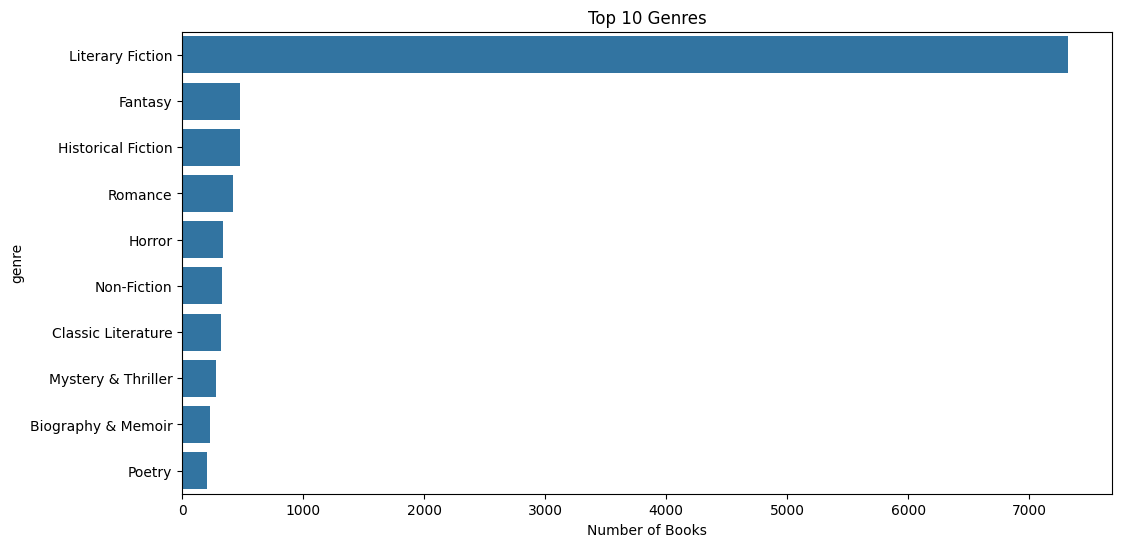

In [ ]:
genre_counts = df['genre'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Top 10 Genres")
plt.xlabel("Number of Books")
plt.savefig('/content/drive/MyDrive/BookProject/chart_a_top_genres.png', dpi=150)
plt.show()

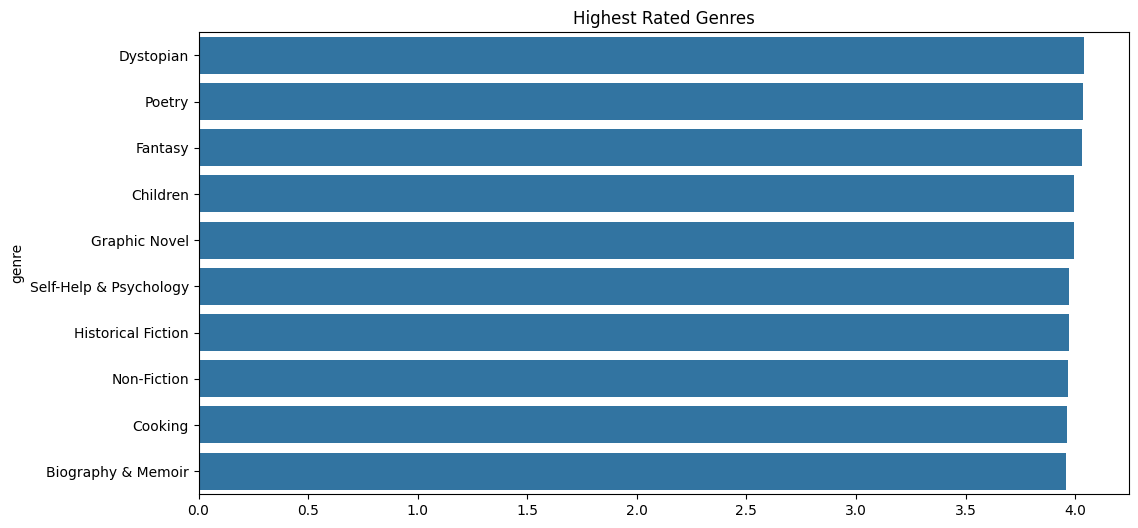

In [ ]:
top_rating = df.groupby("genre")["average_rating"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_rating.values, y=top_rating.index)
plt.title("Highest Rated Genres")
plt.savefig('/content/drive/MyDrive/BookProject/chart_b_highest_rated.png', dpi=150)
plt.show()

In [ ]:
trending = df[df["is_trending_now"] == 1][["title","authors","genre","trend_score"]]

trending.sort_values(by="trend_score", ascending=False).head(10)

,title,authors,genre,trend_score
386,Enthusiasm and Divine Madness,Josef Pieper/Richard Winston/Clara Winston,Literary Fiction,37.51
3934,The Art of Loving,Erich Fromm/Peter D. Kramer/Rainer Funk,Literary Fiction,36.79
9529,A Quick Bite (Argeneau #1),Lynsay Sands,Literary Fiction,36.32
10674,Monster,Walter Dean Myers,Horror,36.03
10620,Object Thinking,David West,Self-Help & Psychology,34.96
1057,The Wish Giver: Three Tales of Coven Tree,Bill Brittain/Andrew Glass,Literary Fiction,34.25
10190,American Genesis: Captain John Smith and the F...,Alden T. Vaughan,Literary Fiction,32.15
2403,Macbeth,William Shakespeare,Classic Literature,31.69
1541,The Client,John Grisham,Literary Fiction,26.02
1781,Never Let Me Go,Kazuo Ishiguro,Literary Fiction,25.54


In [ ]:
def recommend_book(book_name):

    book = df[df["title"].str.contains(book_name, case=False, na=False)]

    if book.empty:
        print("Book not found")
        return

    genre = book.iloc[0]["genre"]

    rec = df[df["genre"] == genre].sort_values(
        by=["recommendation_score","average_rating"],
        ascending=False
    )

    print("Recommended Books:\n")
    print(rec[["title","authors","average_rating"]].head(5))

In [ ]:
import ipywidgets as widgets
from IPython.display import display

txt = widgets.Text(description="Book:")
btn = widgets.Button(description="Recommend")

out = widgets.Output()

def clicked(b):
    with out:
        out.clear_output()
        display(recommend_book(txt.value))

btn.on_click(clicked)

display(txt, btn, out)

Text(value='', description='Book:')

Button(description='Recommend', style=ButtonStyle())

Output()

In [ ]:
bestsellers = df[df["is_bestseller"] == 1]

bestsellers[["title","authors","ratings_count","average_rating"]].head(10)

,title,authors,ratings_count,average_rating
0,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,2095690,4.57
1,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,2153167,4.49
2,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,6333,4.42
3,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,2339585,4.56
4,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,41428,4.78
6,Harry Potter Collection (Harry Potter #1-6),J.K. Rowling,28242,4.73
8,The Ultimate Hitchhiker's Guide to the Galaxy ...,Douglas Adams,249558,4.38
12,A Short History of Nearly Everything,Bill Bryson,248558,4.21
15,In a Sunburned Country,Bill Bryson,72451,4.07
16,I'm a Stranger Here Myself: Notes on Returning...,Bill Bryson,49240,3.90


In [ ]:
future = df.sort_values(by="next_bestseller_score", ascending=False)

future[["title","authors","genre","next_bestseller_score"]].head(10)

,title,authors,genre,next_bestseller_score
10191,Twilight (Twilight #1),Stephenie Meyer,Literary Fiction,79.19
3,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,Fantasy,59.07
0,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,Fantasy,58.58
304,Angels & Demons (Robert Langdon #1),Dan Brown,Horror,58.27
1680,The Hobbit or There and Back Again,J.R.R. Tolkien,Fantasy,57.17
1,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,Fantasy,56.74
23,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. Tolkien,Fantasy,54.27
4365,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling/Mary GrandPré,Fantasy,53.85
7205,The Lightning Thief (Percy Jackson and the Oly...,Rick Riordan,Young Adult,53.60
1447,The Catcher in the Rye,J.D. Salinger,Classic Literature,52.76


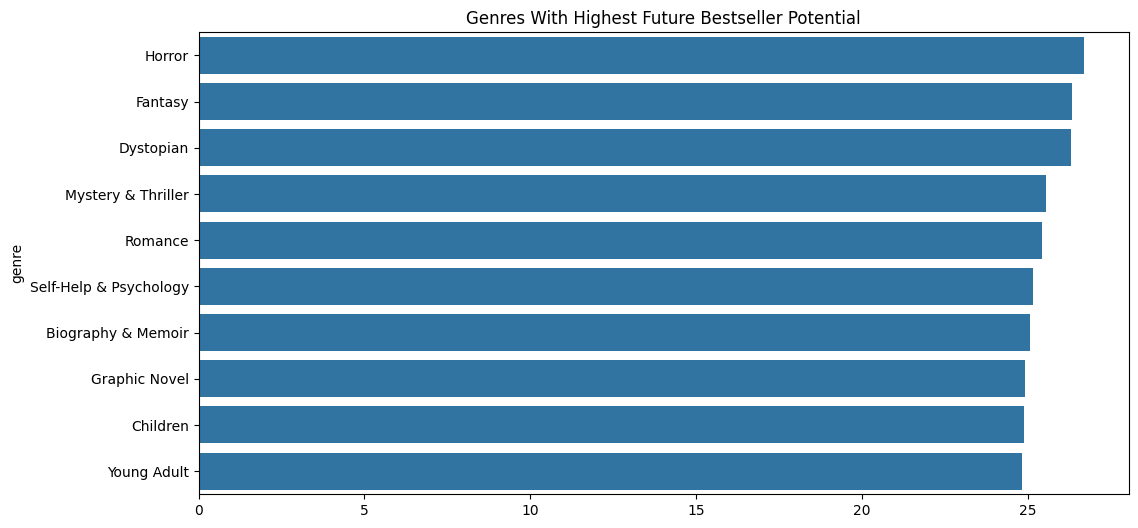

In [ ]:
genre_future = df.groupby("genre")["next_bestseller_score"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=genre_future.values, y=genre_future.index)
plt.title("Genres With Highest Future Bestseller Potential")
plt.savefig('/content/drive/MyDrive/BookProject/chart_c_future_bestseller.png', dpi=150)
plt.show()

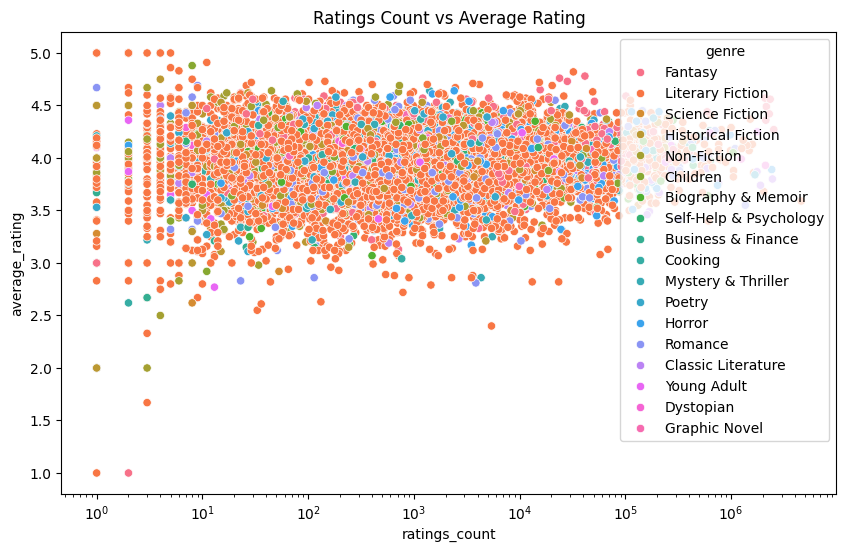

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="ratings_count", y="average_rating", hue="genre")
plt.xscale("log")
plt.title("Ratings Count vs Average Rating")
plt.savefig('/content/drive/MyDrive/BookProject/chart_d_scatter.png', dpi=150)
plt.show()

In [ ]:
gems = df[(df['average_rating'] > 4.5) & (df['ratings_count'] < 5000)]

gems[['title','authors','average_rating']].head(10)

,title,authors,average_rating
145,100 Years of Lynchings,Ralph Ginzburg,4.61
541,Metamorphoses: Volume 2 Books IX-XV,Ovid/Frank Justus Miller,4.52
545,Dionysiac Poetics and Euripides' Bacchae,Charles Segal,4.62
609,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling,4.57
660,The Complete Novels,Jane Austen/Hugh Thomson,4.55
662,Jane Austen: The Complete Novels,Jane Austen,4.55
778,Willem de Kooning: Late Paintings,Julie Sylvester/David Sylvester,5.00
796,Empire 2.0: A Modest Proposal for a United Sta...,Xavier de C./Xavier de C./Joseph Rowe,4.67
799,Novels 1901–1902: The Sacred Fount / The Wings...,Henry James/Leo Bersani,4.63
816,Saul Steinberg: Illuminations,Saul Steinberg/Joel Smith/Charles Simic,4.51


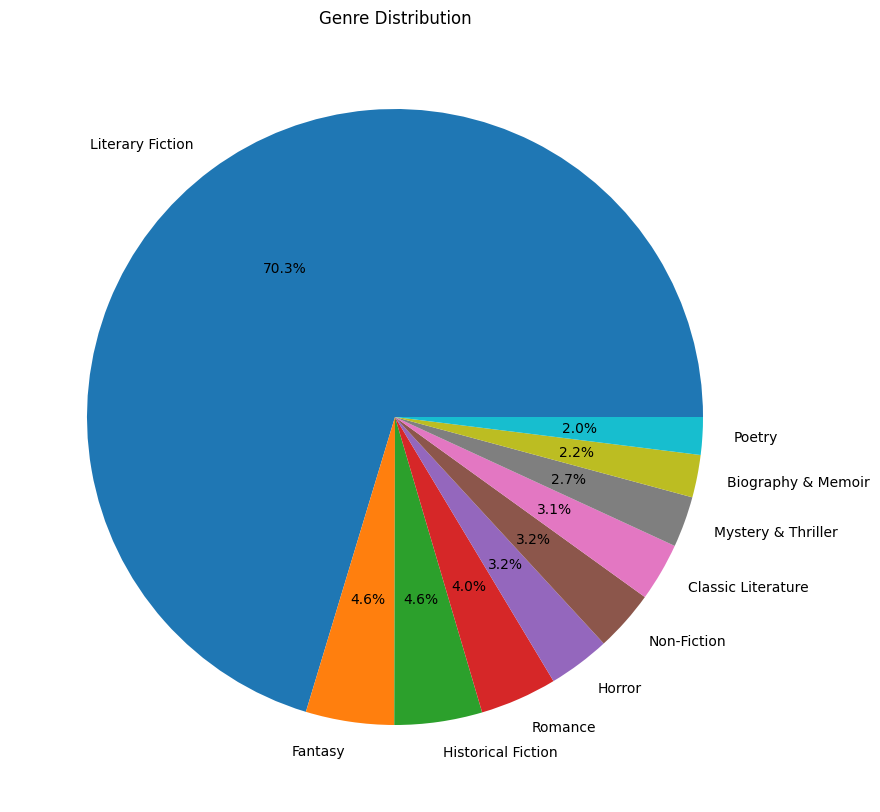

In [ ]:
genre_counts = df['genre'].value_counts().head(10)

plt.figure(figsize=(10,10))

plt.pie(
    genre_counts.values,
    labels=genre_counts.index,
    autopct='%1.1f%%'
)

plt.title("Genre Distribution")

plt.savefig('/content/drive/MyDrive/BookProject/chart_e_genre_pie.png', dpi=150)
plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

/tmp/ipykernel_7874/3874067061.py:1: FutureWarning: The provided callable <function mean at 0x79e701721940> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot = pd.pivot_table(


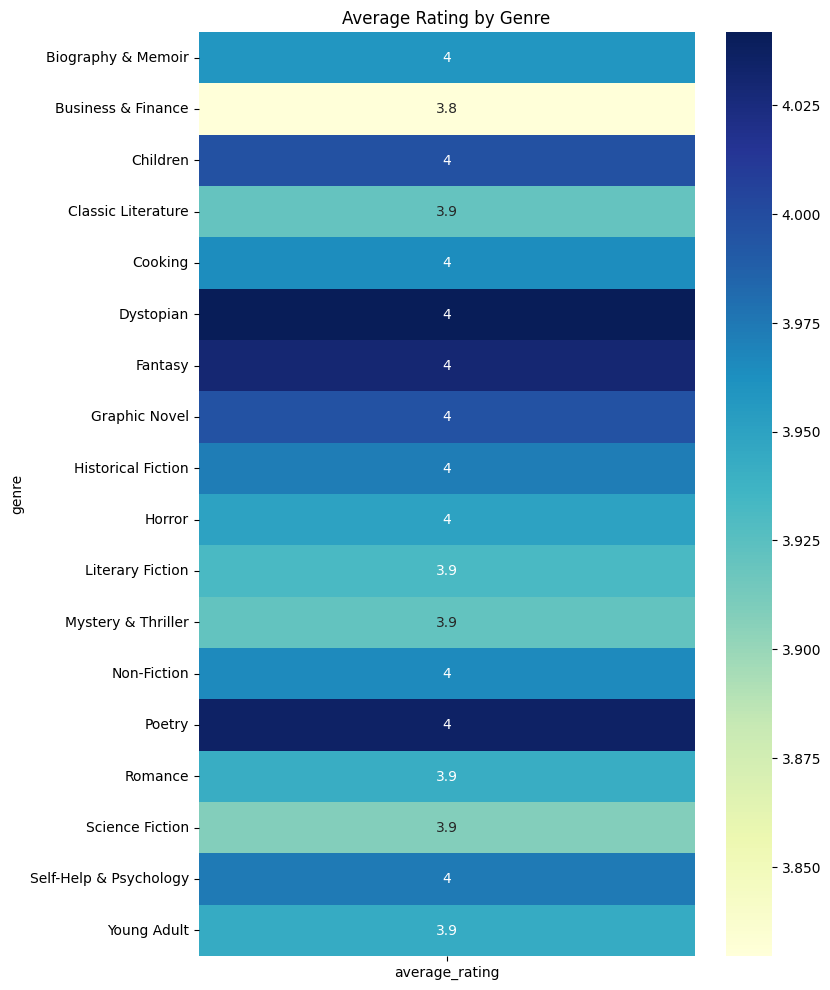

In [ ]:
pivot = pd.pivot_table(
    df,
    values="average_rating",
    index="genre",
    aggfunc=np.mean
)

plt.figure(figsize=(8,12))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Average Rating by Genre")

plt.savefig('/content/drive/MyDrive/BookProject/chart_f_heatmap.png', dpi=150)
plt.show()

# Final Conclusion

1. Fantasy and Fiction dominate book count.
2. Review count strongly affects bestseller success.
3. High ratings alone do not guarantee bestseller status.
4. Some low-popularity books are hidden gems.
5. Machine learning can identify future bestseller potential.

In [ ]:
print("Bestseller breakdown:")
print(df['is_bestseller'].value_counts())
print()
print("Top genres:")
print(df['genre'].value_counts().head(10))
print()
print("Trend tiers:")
print(df['trend_tier'].value_counts())

Bestseller breakdown:
is_bestseller
0    9322
1    1646
Name: count, dtype: int64

Top genres:
genre
Literary Fiction      7317
Fantasy                482
Historical Fiction     479
Romance                420
Horror                 338
Non-Fiction            334
Classic Literature     319
Mystery & Thriller     278
Biography & Memoir     232
Poetry                 205
Name: count, dtype: int64

Trend tiers:
trend_tier
Warming     2774
Cold        2745
Hot         2733
Trending    2716
Name: count, dtype: int64


/tmp/ipykernel_7874/2889328825.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_bs.values, y=genre_bs.index, palette='Set2', ax=ax)


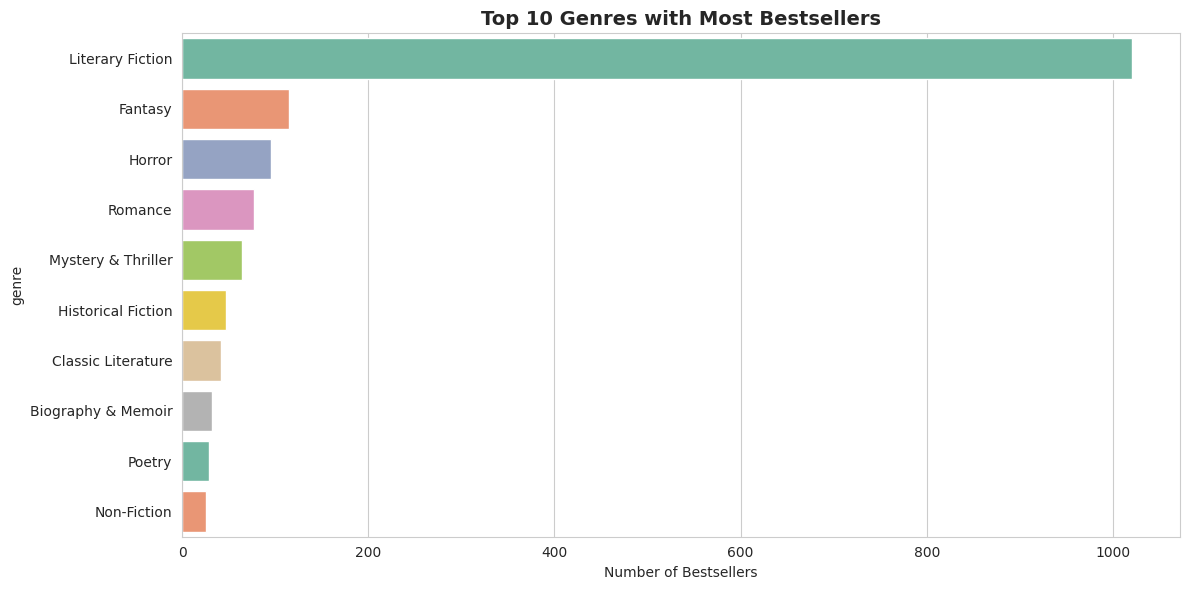

✅ Chart 1 saved!


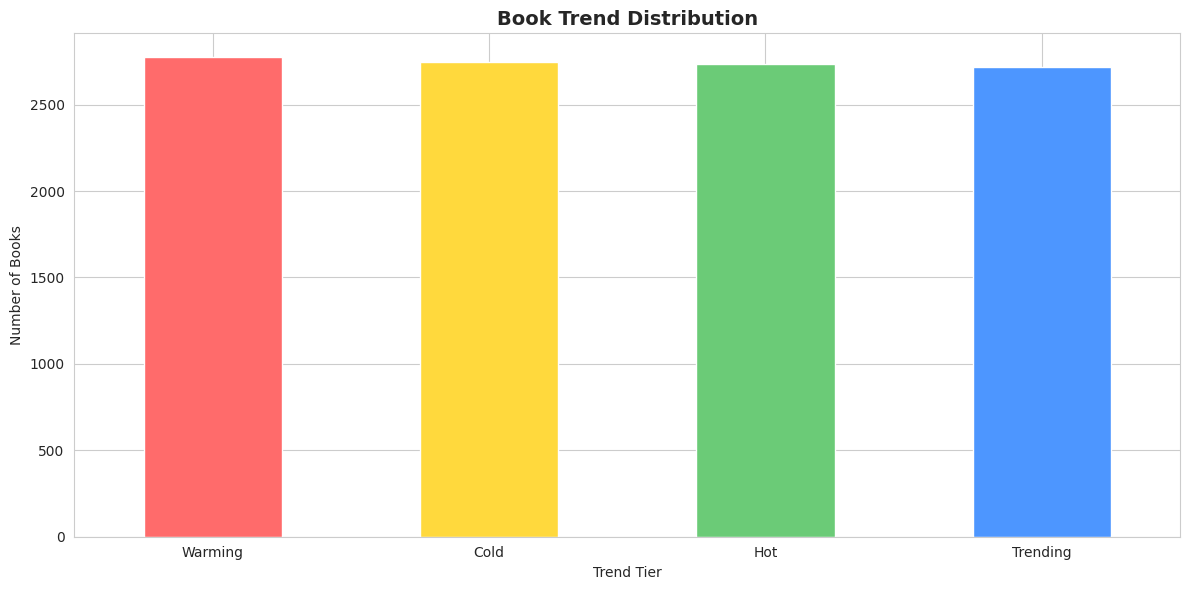

✅ Chart 2 saved!


/tmp/ipykernel_7874/2889328825.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_rating.values, y=genre_rating.index, palette='coolwarm', ax=ax)


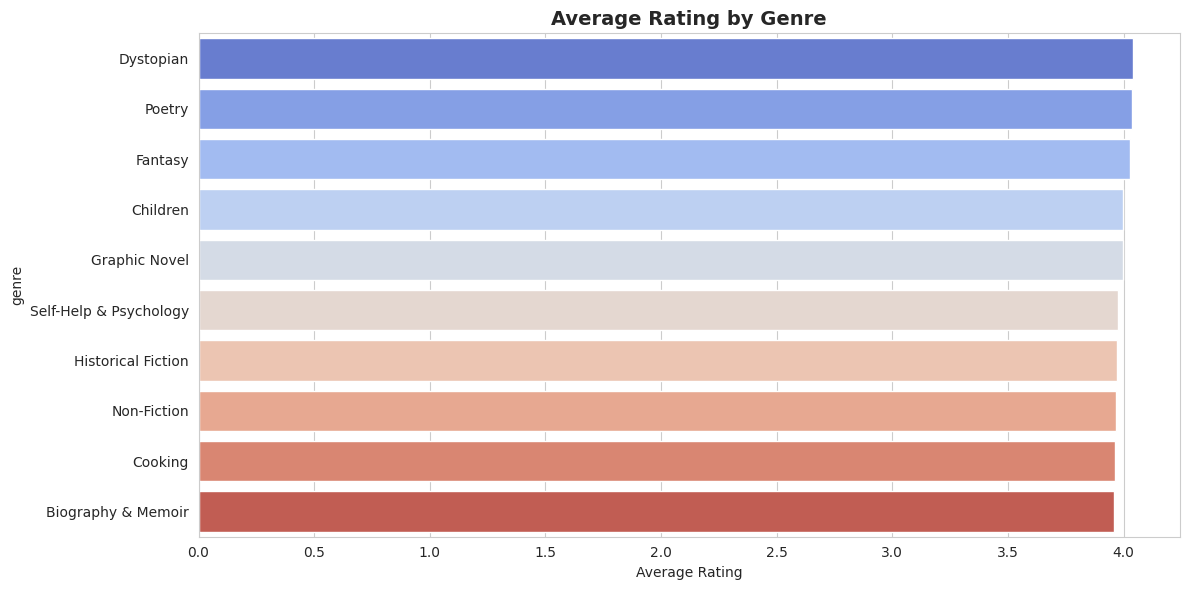

✅ Chart 3 saved!


/tmp/ipykernel_7874/2889328825.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bs_prob.values, y=bs_prob.index, palette='viridis', ax=ax)


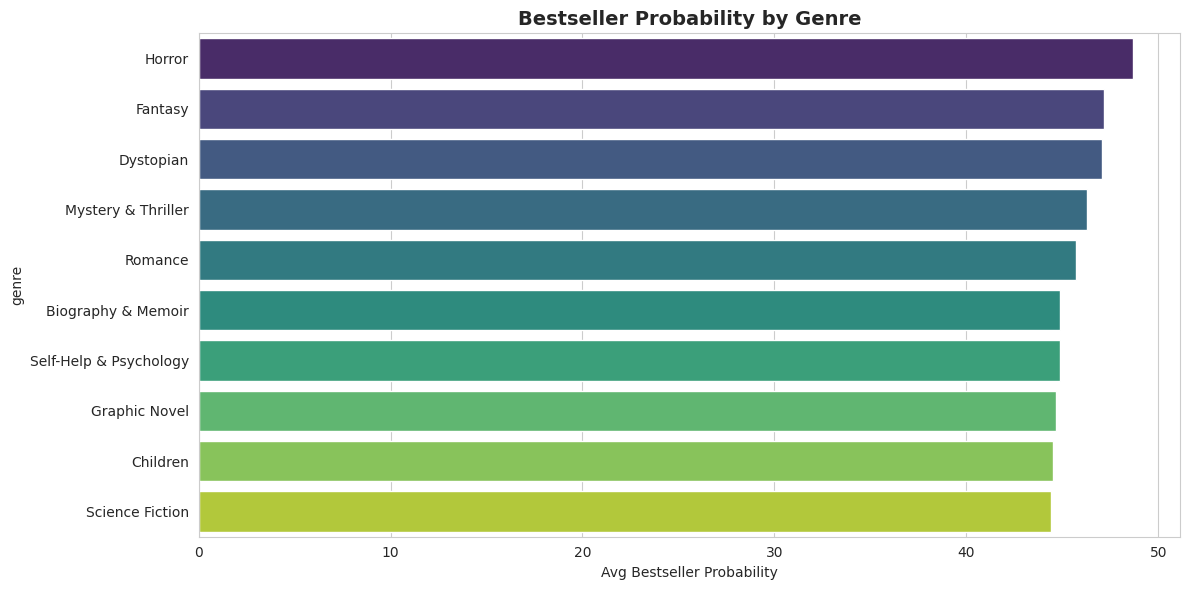

✅ Chart 4 saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

# ── Chart 1: Bestsellers by Genre ──────────────────────
fig, ax = plt.subplots()
genre_bs = df[df['is_bestseller']==1]['genre'].value_counts().head(10)
sns.barplot(x=genre_bs.values, y=genre_bs.index, palette='Set2', ax=ax)
ax.set_title('Top 10 Genres with Most Bestsellers', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Bestsellers')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/BookProject/chart1_genre_bestsellers.png', dpi=150)
plt.show()
print("✅ Chart 1 saved!")

# ── Chart 2: Trend Tier Distribution ───────────────────
fig, ax = plt.subplots()
colors = ['#ff6b6b','#ffd93d','#6bcb77','#4d96ff']
df['trend_tier'].value_counts().plot(kind='bar', color=colors, ax=ax, edgecolor='white')
ax.set_title('Book Trend Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Trend Tier')
ax.set_ylabel('Number of Books')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/BookProject/chart2_trend_tiers.png', dpi=150)
plt.show()
print("✅ Chart 2 saved!")

# ── Chart 3: Average Rating by Genre ───────────────────
fig, ax = plt.subplots()
genre_rating = df.groupby('genre')['average_rating'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=genre_rating.values, y=genre_rating.index, palette='coolwarm', ax=ax)
ax.set_title('Average Rating by Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Rating')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/BookProject/chart3_rating_by_genre.png', dpi=150)
plt.show()
print("✅ Chart 3 saved!")

# ── Chart 4: Bestseller Probability by Genre ───────────
fig, ax = plt.subplots()
bs_prob = df.groupby('genre')['bestseller_probability'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=bs_prob.values, y=bs_prob.index, palette='viridis', ax=ax)
ax.set_title('Bestseller Probability by Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Bestseller Probability')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/BookProject/chart4_bs_probability.png', dpi=150)
plt.show()
print("✅ Chart 4 saved!")

In [ ]:
from scipy import stats

print("=" * 50)
print("HYPOTHESIS TESTING")
print("=" * 50)

# ── H1: Does genre predict bestseller status? ───────────
print("\nH1: Does genre affect bestseller rate?")
genre_groups = [group['is_bestseller'].values
                for _, group in df.groupby('genre')]
f_stat, p_val = stats.f_oneway(*genre_groups)
print(f"F-statistic : {f_stat:.4f}")
print(f"P-value     : {p_val:.6f}")
print("Result:", "✅ REJECT H0 — Genre significantly affects bestseller status"
      if p_val < 0.05 else "❌ No significant difference")

# ── H2: Does rating predict bestseller status? ──────────
print("\nH2: Do bestsellers have higher ratings?")
bs_ratings = df[df['is_bestseller']==1]['average_rating']
non_bs_ratings = df[df['is_bestseller']==0]['average_rating']
t_stat, p_val2 = stats.ttest_ind(bs_ratings, non_bs_ratings)
print(f"Bestseller avg rating     : {bs_ratings.mean():.4f}")
print(f"Non-bestseller avg rating : {non_bs_ratings.mean():.4f}")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_val2:.6f}")
print("Result:", "✅ REJECT H0 — Ratings significantly differ"
      if p_val2 < 0.05 else "❌ No significant difference")

# ── H3: Does trend score predict bestseller? ────────────
print("\nH3: Do bestsellers have higher trend scores?")
bs_trend = df[df['is_bestseller']==1]['trend_score']
non_bs_trend = df[df['is_bestseller']==0]['trend_score']
t_stat3, p_val3 = stats.ttest_ind(bs_trend, non_bs_trend)
print(f"Bestseller avg trend score     : {bs_trend.mean():.4f}")
print(f"Non-bestseller avg trend score : {non_bs_trend.mean():.4f}")
print(f"T-statistic : {t_stat3:.4f}")
print(f"P-value     : {p_val3:.6f}")
print("Result:", "✅ REJECT H0 — Trend score significantly differs"
      if p_val3 < 0.05 else "❌ No significant difference")

# ── H4: Does review count affect bestseller status? ─────
print("\nH4: Do bestsellers have more reviews?")
bs_reviews = df[df['is_bestseller']==1]['text_reviews_count']
non_bs_reviews = df[df['is_bestseller']==0]['text_reviews_count']
t_stat4, p_val4 = stats.ttest_ind(bs_reviews, non_bs_reviews)
print(f"Bestseller avg reviews     : {bs_reviews.mean():.1f}")
print(f"Non-bestseller avg reviews : {non_bs_reviews.mean():.1f}")
print(f"T-statistic : {t_stat4:.4f}")
print(f"P-value     : {p_val4:.6f}")
print("Result:", "✅ REJECT H0 — Review count significantly differs"
      if p_val4 < 0.05 else "❌ No significant difference")

print("\n" + "=" * 50)
print("✅ All hypothesis tests complete!")
print("=" * 50)

HYPOTHESIS TESTING

H1: Does genre affect bestseller rate?
F-statistic : 7.8255
P-value     : 0.000000
Result: ✅ REJECT H0 — Genre significantly affects bestseller status

H2: Do bestsellers have higher ratings?
Bestseller avg rating     : 4.0681
Non-bestseller avg rating : 3.9213
T-statistic : 18.9438
P-value     : 0.000000
Result: ✅ REJECT H0 — Ratings significantly differ

H3: Do bestsellers have higher trend scores?
Bestseller avg trend score     : 21.6340
Non-bestseller avg trend score : 19.6351
T-statistic : 38.6488
P-value     : 0.000000
Result: ✅ REJECT H0 — Trend score significantly differs

H4: Do bestsellers have more reviews?
Bestseller avg reviews     : 3010.8
Non-bestseller avg reviews : 115.0
T-statistic : 45.5286
P-value     : 0.000000
Result: ✅ REJECT H0 — Review count significantly differs

✅ All hypothesis tests complete!


MODEL EVALUATION — RANDOM FOREST
                precision    recall  f1-score   support

Not Bestseller       1.00      1.00      1.00      1863
    Bestseller       0.99      0.98      0.99       331

      accuracy                           1.00      2194
     macro avg       0.99      0.99      0.99      2194
  weighted avg       1.00      1.00      1.00      2194



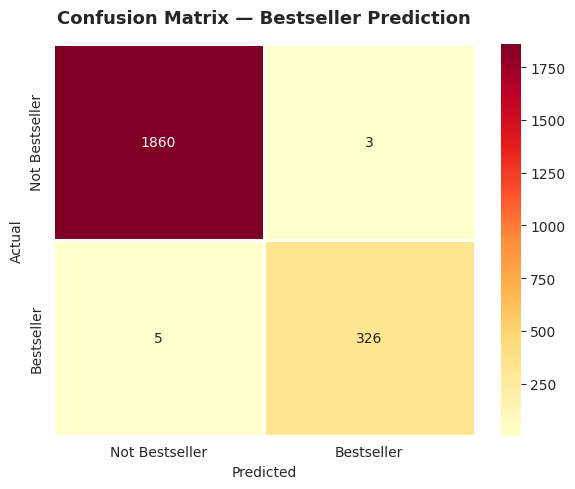

✅ Confusion matrix saved!


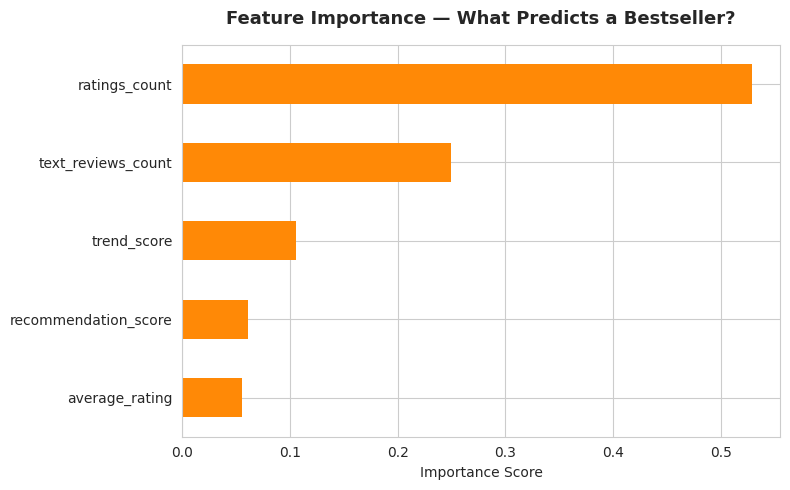

✅ Feature importance chart saved!

✅ Colab analysis COMPLETE!
All charts saved to Google Drive → BookProject folder


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Features
features = [
    'average_rating',
    'ratings_count',
    'text_reviews_count',
    'trend_score',
    'recommendation_score'
]

X = df[features]
y = df['is_bestseller']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ── Accuracy ────────────────────────────────────────────
print("=" * 50)
print("MODEL EVALUATION — RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['Not Bestseller', 'Bestseller']))

# ── Confusion Matrix ────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Not Bestseller','Bestseller'],
            yticklabels=['Not Bestseller','Bestseller'],
            ax=ax, linewidths=2)
ax.set_title('Confusion Matrix — Bestseller Prediction',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/BookProject/chart5_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

# ── Feature Importance ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
importances = pd.Series(
    model.feature_importances_, index=features
).sort_values(ascending=True)
importances.plot(kind='barh', color='#ff8906', ax=ax, edgecolor='none')
ax.set_title('Feature Importance — What Predicts a Bestseller?',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/BookProject/chart6_feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance chart saved!")

print("\n✅ Colab analysis COMPLETE!")
print("All charts saved to Google Drive → BookProject folder")